# Ensemble Member Lineage

`docs/srm-provenance.csv` is a local copy of the [SRM provenance Google Sheet](https://docs.google.com/spreadsheets/d/1HG8PGrkP_pzM99_LvwyIdcCHmSHFdc85FII0N1RYmDk/edit?gid=1557731209#gid=1557731209). Re-export and overwrite that file if the sheet is updated.

This notebook loads the CSV and renders the parent-child lineage for each GCM as side-by-side tables. Rows are coloured by variable group.

- **CESM2-WACCM**: G6-1.5K runs (historical parent + SSP245 bridge) and SSP245 runs (historical parent only). tasmax/tasmin use a different historical parent than standard variables due to a CMIP6 bug fix re-run.
- **MIROC-ES2H**: G6-1.5K and baseline SSP245 runs (historical parent + SSP245 bridge). All variables share the same lineage per member — no per-variable split.

In [1]:
import ast
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
csv_path = Path("../srm-provenance.csv")
raw = pd.read_csv(
    csv_path,
    usecols=["gcm", "experiment_id", "ensemble_id", "variable", "parent_experiment_ensemble_ids"],
)
raw = raw.dropna(subset=["parent_experiment_ensemble_ids"])
raw["parent_experiment_ensemble_ids"] = raw["parent_experiment_ensemble_ids"].apply(
    ast.literal_eval
)


def parse_parents(row):
    return {exp: member for exp, member in row["parent_experiment_ensemble_ids"]}


df = raw.copy()
df["parents"] = df.apply(parse_parents, axis=1)
df["historical_parent"] = df["parents"].apply(lambda p: p.get("historical"))
df["ssp245_parent"] = df["parents"].apply(lambda p: p.get("ssp245"))
df["var_group"] = df["variable"].apply(
    lambda v: "tasmax / tasmin" if v in ("tasmax", "tasmin") else "standard"
)

key_cols = [
    "gcm",
    "experiment_id",
    "ensemble_id",
    "var_group",
    "historical_parent",
    "ssp245_parent",
]
lineage = df[key_cols].drop_duplicates().reset_index(drop=True)
lineage

,gcm,experiment_id,ensemble_id,var_group,historical_parent,ssp245_parent
0,CESM2(WACCM),G6-1.5K,001,standard,r1i1p1f1,001
1,CESM2(WACCM),G6-1.5K,001,tasmax / tasmin,001,009
2,CESM2(WACCM),G6-1.5K,002,standard,r2i1p1f1,002
3,CESM2(WACCM),G6-1.5K,002,tasmax / tasmin,001,007
4,CESM2(WACCM),G6-1.5K,003,standard,r3i1p1f1,003
...,...,...,...,...,...,...
65,MIROC-ES2H,SSP245,r08,tasmax / tasmin,r2i1p4f2,r08
66,MIROC-ES2H,SSP245,r09,standard,r3i1p4f2,r09
67,MIROC-ES2H,SSP245,r09,tasmax / tasmin,r3i1p4f2,r09
68,MIROC-ES2H,SSP245,r10,standard,r1i1p4f2,r10


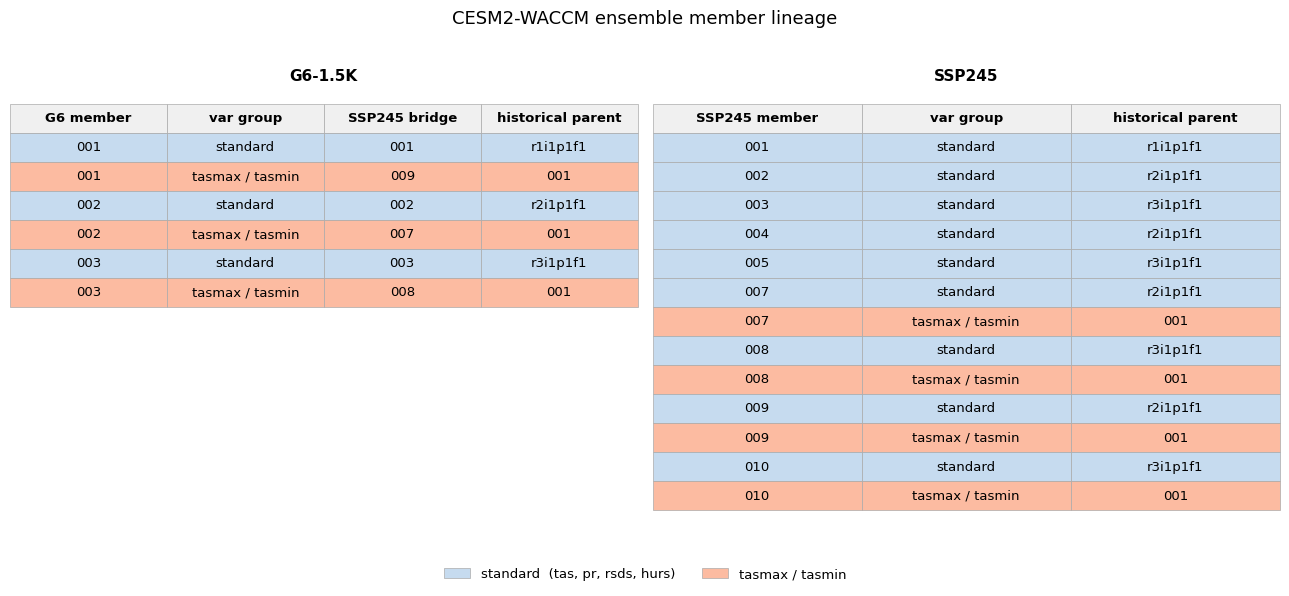

In [3]:
COLOR = {"standard": "#c6dbef", "tasmax / tasmin": "#fcbba1"}
HEADER_COLOR = "#f0f0f0"
EDGE_COLOR = "#aaaaaa"


def build_table_data(gcm_df, scenario):
    rows = gcm_df[gcm_df["experiment_id"] == scenario].sort_values(["ensemble_id", "var_group"])
    is_sai = scenario not in ("SSP245", "ssp245")

    if is_sai:
        col_labels = ["G6 member", "var group", "SSP245 bridge", "historical parent"]
        cell_text = [
            [
                r["ensemble_id"],
                r["var_group"],
                r["ssp245_parent"] or "n/a",
                r["historical_parent"] or "n/a",
            ]
            for _, r in rows.iterrows()
        ]
    else:
        col_labels = ["SSP245 member", "var group", "historical parent"]
        cell_text = [
            [r["ensemble_id"], r["var_group"], r["historical_parent"] or "n/a"]
            for _, r in rows.iterrows()
        ]

    row_colors = [[COLOR[r["var_group"]]] * len(col_labels) for _, r in rows.iterrows()]
    return col_labels, cell_text, row_colors


def draw_lineage_table(ax, col_labels, cell_text, row_colors, title):
    n_cols = len(col_labels)
    header_colors = [[HEADER_COLOR] * n_cols]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellColours=row_colors,
        colColours=header_colors[0],
        cellLoc="center",
        loc="upper center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.6)

    # Thinner cell borders
    for cell in tbl.get_celld().values():
        cell.set_edgecolor(EDGE_COLOR)
        cell.set_linewidth(0.5)

    # Bold header
    for j in range(n_cols):
        tbl[(0, j)].set_text_props(fontweight="bold")

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.axis("off")


# --- Plot ---
cesm_df = lineage[lineage["gcm"] == "CESM2(WACCM)"]

g6_cols, g6_data, g6_colors = build_table_data(cesm_df, "G6-1.5K")
ssp_cols, ssp_data, ssp_colors = build_table_data(cesm_df, "SSP245")

fig, (ax_g6, ax_ssp) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("CESM2-WACCM ensemble member lineage", fontsize=13, y=1.02)

draw_lineage_table(ax_g6, g6_cols, g6_data, g6_colors, "G6-1.5K")
draw_lineage_table(ax_ssp, ssp_cols, ssp_data, ssp_colors, "SSP245")

handles = [
    mpatches.Patch(
        color=COLOR["standard"], label="standard  (tas, pr, rsds, hurs)", ec=EDGE_COLOR, lw=0.5
    ),
    mpatches.Patch(color=COLOR["tasmax / tasmin"], label="tasmax / tasmin", ec=EDGE_COLOR, lw=0.5),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    fontsize=9.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.show()

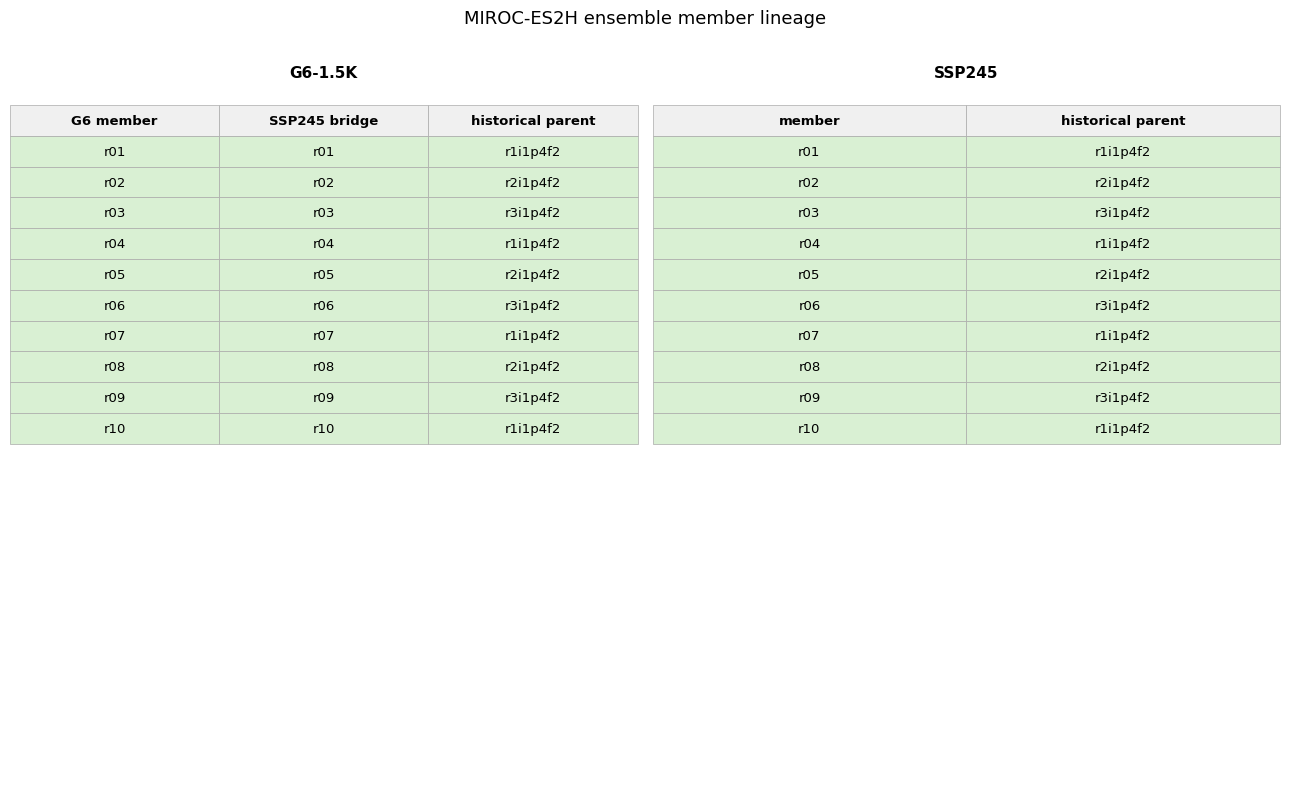

In [4]:
miroc_df = lineage[lineage["gcm"] == "MIROC-ES2H"].drop(columns="var_group").drop_duplicates()

MIROC_ROW_COLOR = "#d9f0d3"


def build_miroc_table(df, scenario):
    rows = df[df["experiment_id"] == scenario].sort_values("ensemble_id")
    is_sai = scenario not in ("SSP245", "ssp245")
    if is_sai:
        col_labels = ["G6 member", "SSP245 bridge", "historical parent"]
        cell_text = [
            [r["ensemble_id"], r["ssp245_parent"] or "n/a", r["historical_parent"] or "n/a"]
            for _, r in rows.iterrows()
        ]
    else:
        col_labels = ["member", "historical parent"]
        cell_text = [
            [r["ensemble_id"], r["historical_parent"] or "n/a"] for _, r in rows.iterrows()
        ]
    row_colors = [[MIROC_ROW_COLOR] * len(col_labels) for _ in rows.iterrows()]
    return col_labels, cell_text, row_colors


g6_cols, g6_data, g6_colors = build_miroc_table(miroc_df, "G6-1.5K")

bl_display = miroc_df
bl_cols, bl_data, bl_colors = build_miroc_table(bl_display, "SSP245")

fig, (ax_g6, ax_bl) = plt.subplots(1, 2, figsize=(13, 8))
fig.suptitle("MIROC-ES2H ensemble member lineage", fontsize=13, y=1.01)

draw_lineage_table(ax_g6, g6_cols, g6_data, g6_colors, "G6-1.5K")
draw_lineage_table(ax_bl, bl_cols, bl_data, bl_colors, "SSP245")

plt.tight_layout()
plt.show()